# DTGS162. Optimizing parameters of a differentiable model

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/4-developers/DTGS162_differentiable_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

DeepTrack simulations can participate directly in PyTorch computation graphs. This makes it possible to optimize physical and acquisition parameters by backpropagating an image-domain loss through the simulation.

In this tutorial, you will recover the position and radius of a `MieSphere` from a target brightfield image. The same pattern applies to other continuous properties implemented by differentiable operations.

In [2]:
from __future__ import annotations

import deeptrack as dt
import matplotlib.pyplot as plt
import numpy as np
import torch


torch.manual_seed(0)
torch.set_default_dtype(torch.float64)

## 1. Creating a target image

Start by defining a microscope and a particle with known properties. The target image represents the observation whose parameters you want to recover.

The backend context makes every compatible operation return PyTorch tensors while leaving the global backend unchanged after the block.

In [3]:
config = dt.backend.config

true_position = (15.5, 17.25)  # px
true_radius_um = 0.55
refractive_index = 1.45

with config.with_backend("torch"):
    microscope = dt.Brightfield(
        NA=0.7,
        wavelength=680e-9,
        refractive_index_medium=1.33,
        resolution=1e-6,
        magnification=10,
        output_region=(0, 0, 32, 32),
        padding=(4, 4, 4, 4),
    )

    mie_properties = dict(
        position_unit="pixel",
        input_polarization=0.0,
        output_polarization=0.0,
        L=5,
        collection_angle=0.3,
        offset_z=1e-5,
        mode="hybrid",
    )

    target_particle = dt.MieSphere(
        position=true_position,
        radius=true_radius_um * 1e-6,
        refractive_index=refractive_index,
        **mie_properties,
    )
    target_image = microscope(target_particle).update()().detach()

## 2. Defining learnable properties

PyTorch optimizers update instances of `torch.nn.Parameter`. Here, both particle position and radius are learnable. The properties are supplied as functions so that DeepTrack creates a fresh computation graph whenever the pipeline is updated.

We initialize the learnable properties with our best guess of the target values. The optimizer will update these values to minimize the loss.

Radius is optimized in micrometers and converted to meters inside the property function. Keeping learnable values near unit scale improves numerical conditioning.

In [4]:
initial_position = (13.0, 14.5)  # px
initial_radius_um = 0.40

position = torch.nn.Parameter(torch.tensor(initial_position))
radius_um = torch.nn.Parameter(torch.tensor(initial_radius_um))

with config.with_backend("torch"):
    fitted_particle = dt.MieSphere(
        position=lambda: (position[0], position[1]),
        radius=lambda: radius_um * 1e-6,
        refractive_index=refractive_index,
        **mie_properties,
    )
    fitted_pipeline = microscope(fitted_particle)
    initial_image = fitted_pipeline.update()().detach()

The parameters use separate learning rates because a useful step in pixels is much larger than a useful step in micrometers.

In [5]:
optimizer = torch.optim.Adam(
    [
        {"params": [position], "lr": 0.15},
        {"params": [radius_um], "lr": 0.01},
    ]
)

## 3. Running the optimization

At each step, calculate the mean squared error between the simulated and target images and backpropagate it to the particle properties.

DeepTrack caches resolved feature values. Calling `update()` after each optimizer step invalidates that cache and rebuilds the image from the new parameter values.

In [6]:
history = {"loss": [], "x": [], "y": [], "radius_um": []}

with config.with_backend("torch"):
    for _ in range(150):
        optimizer.zero_grad()

        fitted_image = fitted_pipeline.update()()
        loss = torch.mean((fitted_image - target_image) ** 2)
        loss.backward()
        optimizer.step()

        history["loss"].append(loss.detach().item())
        history["x"].append(position[0].detach().item())
        history["y"].append(position[1].detach().item())
        history["radius_um"].append(radius_um.detach().item())

optimized_image = fitted_pipeline.update()().detach()
history = {name: np.asarray(values) for name, values in history.items()}

print("Parameter          Target       Fitted")
print(f"x position [px]   {true_position[0]:8.3f}   {position[0].item():8.3f}")
print(f"y position [px]   {true_position[1]:8.3f}   {position[1].item():8.3f}")
print(f"radius [um]       {true_radius_um:8.3f}   {radius_um.item():8.3f}")
print(f"final MSE                    {history['loss'][-1]:.3e}")

Parameter          Target       Fitted
x position [px]     15.500     15.500
y position [px]     17.250     17.250
radius [um]          0.550      0.550
final MSE                    1.157e-10


## 4. Inspecting the result

The loss and parameter histories show how the optimizer moves through the differentiable simulation toward the target properties.

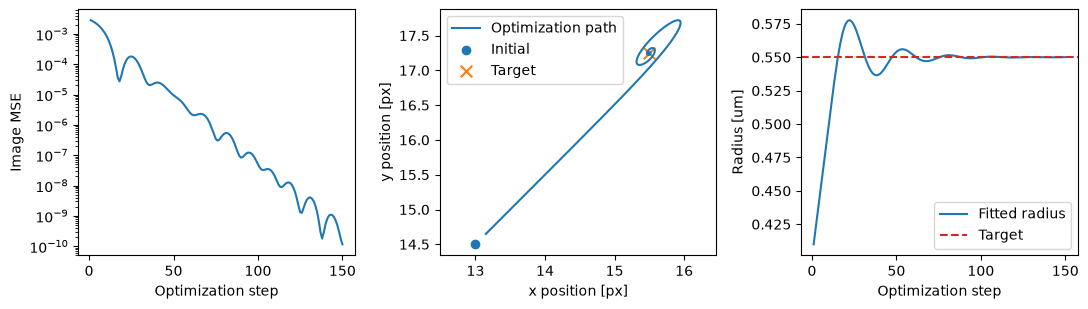

In [7]:
steps = np.arange(1, len(history["loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

axes[0].semilogy(steps, history["loss"])
axes[0].set(xlabel="Optimization step", ylabel="Image MSE")

axes[1].plot(history["x"], history["y"], label="Optimization path")
axes[1].scatter(*initial_position, marker="o", label="Initial")
axes[1].scatter(*true_position, marker="x", s=70, label="Target")
axes[1].set(xlabel="x position [px]", ylabel="y position [px]")
axes[1].axis("equal")
axes[1].legend()

axes[2].plot(steps, history["radius_um"], label="Fitted radius")
axes[2].axhline(true_radius_um, color="tab:red", linestyle="--", label="Target")
axes[2].set(xlabel="Optimization step", ylabel="Radius [um]")
axes[2].legend()

fig.tight_layout()

Finally, compare the target, initial, and optimized images.

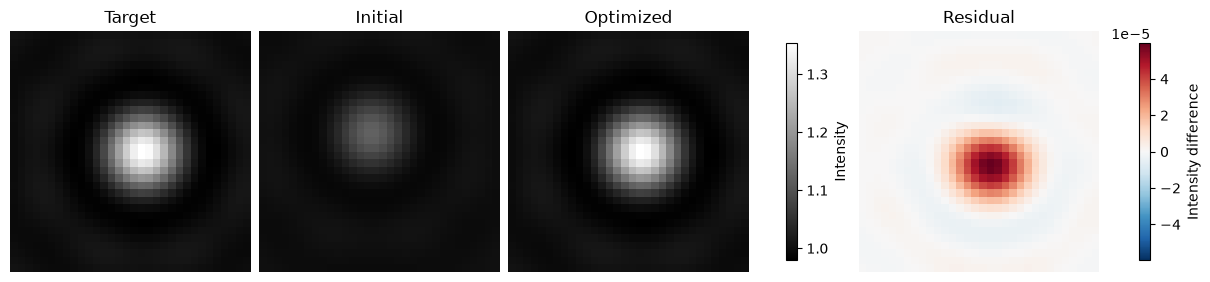

In [8]:
target = target_image[..., 0].cpu().numpy()
initial = initial_image[..., 0].cpu().numpy()
optimized = optimized_image[..., 0].cpu().numpy()
residual = optimized - target

intensity_limits = (
    min(target.min(), initial.min(), optimized.min()),
    max(target.max(), initial.max(), optimized.max()),
)
residual_limit = np.max(np.abs(residual))

fig, axes = plt.subplots(1, 4, figsize=(12, 3), constrained_layout=True)
for axis, image, title in zip(
    axes[:3],
    (target, initial, optimized),
    ("Target", "Initial", "Optimized"),
):
    view = axis.imshow(image, cmap="gray", vmin=intensity_limits[0], vmax=intensity_limits[1])
    axis.set_title(title)
    axis.axis("off")

residual_view = axes[3].imshow(
    residual,
    cmap="RdBu_r",
    vmin=-residual_limit,
    vmax=residual_limit,
)
axes[3].set_title("Residual")
axes[3].axis("off")

fig.colorbar(view, ax=axes[:3], shrink=0.75, label="Intensity")
fig.colorbar(residual_view, ax=axes[3], shrink=0.75, label="Intensity difference");

The recovered position and radius closely match the target values. This workflow can be extended to other continuous scatterer or microscope properties, provided all operations between the parameter and loss support PyTorch autograd.

**NOTE:** Differentiability does not guarantee that parameters are uniquely identifiable. Discrete choices such as `L`, `mode`, and the output region should remain fixed during gradient-based optimization, and correlated physical parameters may require additional observations or constraints.